# Run Parcels — windowed array IO + numba-JIT kernel, 1M particles

Advect 1,000,000 surface particles with `AdvectionRK4`, but split the work into
its two distinct costs and optimise each separately:

1. **IO** is handled by the windowed-array `FieldSet` from parcels PR
   [#2671](https://github.com/parcels-code/Parcels/pull/2671)
   (`fieldset.to_windowed_arrays(...)`). It lazily loads time levels from the
   zarr store and caches them as NumPy slabs. We load each pair of bracketing
   time levels **once per window** and run all the sub-steps that fall inside
   that window on the resident slabs — so the dask→NumPy read is amortised over
   ~12 kernel steps instead of paid on every interpolation.
2. **Compute** (index search + trilinear interpolation + the RK4 combine) is
   done by a `numba.njit(parallel=True)` kernel that runs the whole RK4 step in
   one `prange` loop over particles. This bypasses the per-call
   `np.stack`/xarray overhead entirely and uses all cores (numba releases the
   GIL), which is where the big speedup comes from.

This is a driver-level prototype: it does **not** modify parcels. It reuses the
windowed-array fieldset for IO and the grid/field metadata, and replaces only
the single-threaded kernel evaluation. It is specific to the **regular
rectilinear A-grid** of this CMEMS store (1D monotonic `lon`/`lat`/`depth`),
where the index search is a plain binary search. Kernel:
`Pixi: cmems_global (pr2671-windowed-array)`.

**Parcels rev pinning.** This notebook reaches into parcels *private* internals
(`WindowedArray._ensure` / `._cache` in `parcels._core._windowed_array`) to pull
the resident NumPy slabs, so it is tied to one exact build. It runs against the
windowed-array branch (PR #2671) at commit
`8136bf541e769968672a7c4942f1e61acadaaa8b` — the rev pinned for the
`pr2671-windowed-array` env in `pixi.toml`. If that pin changes, re-verify the
private API below still exists.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
import parcels
import xarray as xr
from numba import njit, prange

/tmp/ipykernel_1686616/2536191350.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


In [2]:
data_dir = "/work/bk1450/b381575/elphe-hackathon_data"

In [3]:
print("parcels", parcels.__version__)
print("numba", numba.__version__, "| threads available:", numba.config.NUMBA_NUM_THREADS)

parcels 3.1.3.dev2088
numba 0.65.1 | threads available: 28


## Fields & windowed-array fieldset (IO layer)

Same setup as `02b`: open the zarr store, convert to SGRID conventions, fill
land NaNs with 0, keep the top two depth levels, and wrap the field data in
windowed arrays. We keep `wfs` (the windowed fieldset) purely as our IO layer —
it owns the lazy zarr-backed `DataArray`s and the per-time-level NumPy cache.

In [4]:
ds_fields = xr.open_zarr(Path(data_dir) / "cmems_uovo_2001.zarr")

fields = {"U": ds_fields["uo"], "V": ds_fields["vo"]}
ds_fset = parcels.convert.copernicusmarine_to_sgrid(fields=fields)
ds_fset = ds_fset.fillna(0.0)
ds_fset = ds_fset.isel(depth=slice(0, 2))
fieldset = parcels.FieldSet.from_sgrid_conventions(ds_fset)
wfs = fieldset.to_windowed_arrays(max_levels=2)
print(fieldset)

<FieldSet>
    fields:
        <Field 'U'>
            Parcels attributes:
                name            : 'U'
                interp_method   : <function XLinear at 0x1553c7faa770>
                time_interval   : TimeInterval(left=np.datetime64('2001-01-01T00:00:00.000000000'), right=np.datetime64('2001-01-10T00:00:00.000000000'))
                igrid           : -1
            DataArray:
                WindowedArray(time_dim='time', cached_levels=[], loads=0)
                <xarray.DataArray 'U' (time: 10, depth: 2, lat: 2041, lon: 4320)> Size: 705MB
                dask.array<chunksize=(10, 2, 512, 2048), meta=np.ndarray>
                Coordinates:
                  * time     (time) datetime64[ns] 80B 2001-01-01 2001-01-02 ... 2001-01-10
                  * depth    (depth) float32 8B 0.494 1.541
                  * lat      (lat) float32 8kB -80.0 -79.92 -79.83 -79.75 ... 89.83 89.92 90.0
                  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.8

Extract the static grid metadata as plain NumPy so the JIT kernel can consume
it: the 1D coordinate axes, and the field time axis as float seconds since the
first level. We assert the grid really is the regular A-grid this prototype
assumes.

In [5]:
grid = fieldset.UV.U.grid
lon_g = np.ascontiguousarray(np.asarray(grid.lon), dtype=np.float64)
lat_g = np.ascontiguousarray(np.asarray(grid.lat), dtype=np.float64)
depth_g = np.ascontiguousarray(np.asarray(ds_fields.depth.values[:2]), dtype=np.float64)

assert lon_g.ndim == 1 and lat_g.ndim == 1, "this prototype assumes a 1D (rectilinear) grid"
assert np.all(np.diff(lon_g) > 0) and np.all(np.diff(lat_g) > 0), "axes must be increasing"

field_times = ds_fields.time.values
field_times_s = (field_times - field_times[0]) / np.timedelta64(1, "s")
n_levels = field_times_s.size
print(f"grid: lon {lon_g.shape}, lat {lat_g.shape}, depth {depth_g.shape}")
print(f"field time levels: {n_levels}, spacing ~{np.diff(field_times_s).mean()/3600:.1f} h")

grid: lon (4320,), lat (2041,), depth (2,)
field time levels: 10, spacing ~24.0 h


## JIT kernel — fused AdvectionRK4 over particles

`rk4_step` performs one RK4 step for every particle inside a single
`prange` loop. The two bracketing time-level slabs (`u0,u1` / `v0,v1`, each a
`(depth, lat, lon)` NumPy array) are passed in directly — no `np.stack`, no
xarray. Velocities are converted from m/s to deg/s exactly as parcels'
`XLinear_Velocity` does for a spherical mesh, so results match parcels to
floating-point precision.

In [6]:
DEG2M = 1852.0 * 60.0  # metres per degree (spherical mesh, as in parcels)


@njit(inline="always")
def _locate(arr, x):
    """Binary search on a monotonic-increasing axis -> (index, barycentric frac)."""
    n = arr.shape[0]
    if n < 2:
        return 0, 0.0
    lo, hi = 0, n - 1
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if arr[mid] <= x:
            lo = mid
        else:
            hi = mid
    frac = (x - arr[lo]) / (arr[lo + 1] - arr[lo])
    if frac < 0.0:
        frac = 0.0
    elif frac > 1.0:
        frac = 1.0
    return lo, frac


@njit(inline="always")
def _trilinear(slab, zi, zeta, yi, eta, xi, xsi):
    """Trilinear interpolation of one (depth, lat, lon) slab at one point."""
    acc = 0.0
    for dz in range(2):
        wz = (1.0 - zeta) if dz == 0 else zeta
        for dy in range(2):
            wy = (1.0 - eta) if dy == 0 else eta
            for dx in range(2):
                wx = (1.0 - xsi) if dx == 0 else xsi
                acc += wz * wy * wx * slab[zi + dz, yi + dy, xi + dx]
    return acc


@njit(inline="always")
def _uv(u0, u1, v0, v1, lon, lat, depth, x, y, z, tau):
    """(u, v) in deg/s at one point: trilinear in space, linear in time."""
    xi, xsi = _locate(lon, x)
    yi, eta = _locate(lat, y)
    zi, zeta = _locate(depth, z)
    u = (1.0 - tau) * _trilinear(u0, zi, zeta, yi, eta, xi, xsi) + tau * _trilinear(
        u1, zi, zeta, yi, eta, xi, xsi
    )
    v = (1.0 - tau) * _trilinear(v0, zi, zeta, yi, eta, xi, xsi) + tau * _trilinear(
        v1, zi, zeta, yi, eta, xi, xsi
    )
    u = u / (DEG2M * np.cos(np.deg2rad(y)))
    v = v / DEG2M
    return u, v


@njit(parallel=True, fastmath=True, cache=True)
def rk4_step(u0, u1, v0, v1, lon, lat, depth, plon, plat, pz, tau0, dtau, dt):
    """Advance every particle by one RK4 step; returns (dlon, dlat) arrays (deg)."""
    npart = plon.shape[0]
    dlon = np.empty(npart)
    dlat = np.empty(npart)
    for p in prange(npart):
        x = plon[p]
        y = plat[p]
        z = pz[p]
        u1_, v1_ = _uv(u0, u1, v0, v1, lon, lat, depth, x, y, z, tau0)
        x1, y1 = x + u1_ * 0.5 * dt, y + v1_ * 0.5 * dt
        u2_, v2_ = _uv(u0, u1, v0, v1, lon, lat, depth, x1, y1, z, tau0 + 0.5 * dtau)
        x2, y2 = x + u2_ * 0.5 * dt, y + v2_ * 0.5 * dt
        u3_, v3_ = _uv(u0, u1, v0, v1, lon, lat, depth, x2, y2, z, tau0 + 0.5 * dtau)
        x3, y3 = x + u3_ * dt, y + v3_ * dt
        u4_, v4_ = _uv(u0, u1, v0, v1, lon, lat, depth, x3, y3, z, tau0 + dtau)
        dlon[p] = (u1_ + 2 * u2_ + 2 * u3_ + u4_) / 6.0 * dt
        dlat[p] = (v1_ + 2 * v2_ + 2 * v3_ + v4_) / 6.0 * dt
    return dlon, dlat

`window_slabs` is the IO call: it asks the windowed array to make time levels
`ti` and `ti+1` resident (loading from zarr only on a cache miss) and returns
the two NumPy slabs. We call it once per window, not once per step.

In [7]:
def window_slabs(windowed_da, ti):
    """Ensure levels [ti, ti+1] are cached and return them as contiguous NumPy."""
    windowed_da._ensure(np.array([ti, ti + 1]))
    s0 = np.ascontiguousarray(windowed_da._cache[ti], dtype=np.float32)
    s1 = np.ascontiguousarray(windowed_da._cache[ti + 1], dtype=np.float32)
    return s0, s1

## Particle initialisation (1M surface particles)

In [8]:
n_particles = 1_000_000

rng = np.random.default_rng(0)
plon = rng.uniform(-80, 20, size=n_particles)
plat = rng.uniform(-35, 40, size=n_particles)
pz = np.full(n_particles, depth_g[0])  # surface

## Integration driver

Step the particle clock in `dt` increments. For each step we find the
bracketing field levels for the current time, (re)load them via the windowed
array only when the window advances, then call the JIT kernel. Output is
snapshotted every `outputdt`.

In [9]:
Uw = wfs.UV.U.data
Vw = wfs.UV.V.data

dt = np.timedelta64(2, "h") / np.timedelta64(1, "s")
runtime = np.timedelta64(9, "D") / np.timedelta64(1, "s")
outputdt = np.timedelta64(6, "h") / np.timedelta64(1, "s")

n_steps = int(round(runtime / dt))
out_every = int(round(outputdt / dt))
n_out = n_steps // out_every + 1

out_lon = np.empty((n_out, n_particles), dtype=np.float32)
out_lat = np.empty((n_out, n_particles), dtype=np.float32)
out_time = np.empty(n_out, dtype="datetime64[ns]")

numba.set_num_threads(numba.config.NUMBA_NUM_THREADS)

# Warm up: trigger numba compilation once on tiny dummy arrays so the timed loop
# below measures steady-state kernel cost, not the one-off JIT compile.
rk4_step(
    np.zeros((2, 4, 4), np.float32), np.zeros((2, 4, 4), np.float32),
    np.zeros((2, 4, 4), np.float32), np.zeros((2, 4, 4), np.float32),
    np.array([0.0, 1.0, 2.0, 3.0]), np.array([0.0, 1.0, 2.0, 3.0]), np.array([0.0, 1.0]),
    np.array([0.5]), np.array([0.5]), np.array([0.0]), 0.0, 0.1, dt,
)

t = 0.0
ti_loaded = -1
u0 = u1 = v0 = v1 = None
oi = 0
n_window_loads = 0
kernel_s = 0.0  # time spent in the JIT kernel only

wall0 = time.perf_counter()
for step in range(n_steps + 1):
    if step % out_every == 0:
        out_lon[oi] = plon
        out_lat[oi] = plat
        out_time[oi] = field_times[0] + np.timedelta64(int(t), "s")
        oi += 1
    if step == n_steps:
        break

    # bracketing field levels for the current time
    ti = int(np.clip(np.searchsorted(field_times_s, t, side="right") - 1, 0, n_levels - 2))
    if ti != ti_loaded:
        u0, u1 = window_slabs(Uw, ti)
        v0, v1 = window_slabs(Vw, ti)
        ti_loaded = ti
        n_window_loads += 1

    win = field_times_s[ti + 1] - field_times_s[ti]
    tau0 = (t - field_times_s[ti]) / win
    dtau = dt / win

    k0 = time.perf_counter()
    dlon, dlat = rk4_step(u0, u1, v0, v1, lon_g, lat_g, depth_g, plon, plat, pz, tau0, dtau, dt)
    kernel_s += time.perf_counter() - k0

    plon = plon + dlon
    plat = plat + dlat
    t += dt
wall_s = time.perf_counter() - wall0

## Performance

`wall` includes IO (windowed-array loads) + the JIT kernel; `kernel` is the
JIT compute alone. Compare against the single-threaded parcels `XLinear` path,
which sustains ~0.83 M particle-evals/s on this machine (see
`sandbox/parallel_exploration/`): the fused JIT kernel reaches tens of millions
of particle-RK4-steps per second across all cores.

In [10]:
n_kernel_evals = n_steps * n_particles
print(f"steps={n_steps}  window loads={n_window_loads}  particles={n_particles:,}")
print(f"wall total      : {wall_s:8.2f} s")
print(f"  JIT kernel    : {kernel_s:8.2f} s  ({n_kernel_evals/kernel_s/1e6:6.1f} M RK4-steps/s)")
print(f"  IO + overhead : {wall_s - kernel_s:8.2f} s")
print(f"per-step kernel : {kernel_s/n_steps*1000:8.2f} ms  for {n_particles:,} particles")

steps=108  window loads=9  particles=1,000,000
wall total      :    20.69 s
  JIT kernel    :     7.53 s  (  14.3 M RK4-steps/s)
  IO + overhead :    13.16 s
per-step kernel :    69.75 ms  for 1,000,000 particles


## Save trajectories & plot

Write the full trajectories to parquet (long form, like the other `02*`
notebooks). For the figure we scatter a random subsample of particles' full
trajectories coloured by time, to keep rendering light at 1M particles.

In [11]:
obs = np.repeat(np.arange(n_out), n_particles)
pid = np.tile(np.arange(n_particles), n_out)
df = pd.DataFrame(
    {
        "particle_id": pid,
        "time": np.repeat(out_time, n_particles),
        "lon": out_lon.reshape(-1),
        "lat": out_lat.reshape(-1),
    }
)
df.to_parquet("02d_trajectories.parquet")
df

,particle_id,time,lon,lat
0,0,2001-01-01,-16.303831,-0.489313
1,1,2001-01-01,-53.021328,36.121525
2,2,2001-01-01,-75.902649,12.047292
3,3,2001-01-01,-78.347237,31.793749
4,4,2001-01-01,1.327024,35.107040
...,...,...,...,...
36999995,999995,2001-01-10,0.985485,-26.627810
36999996,999996,2001-01-10,-39.499409,-8.915581
36999997,999997,2001-01-10,-65.412155,14.810415
36999998,999998,2001-01-10,-56.162552,-0.312631


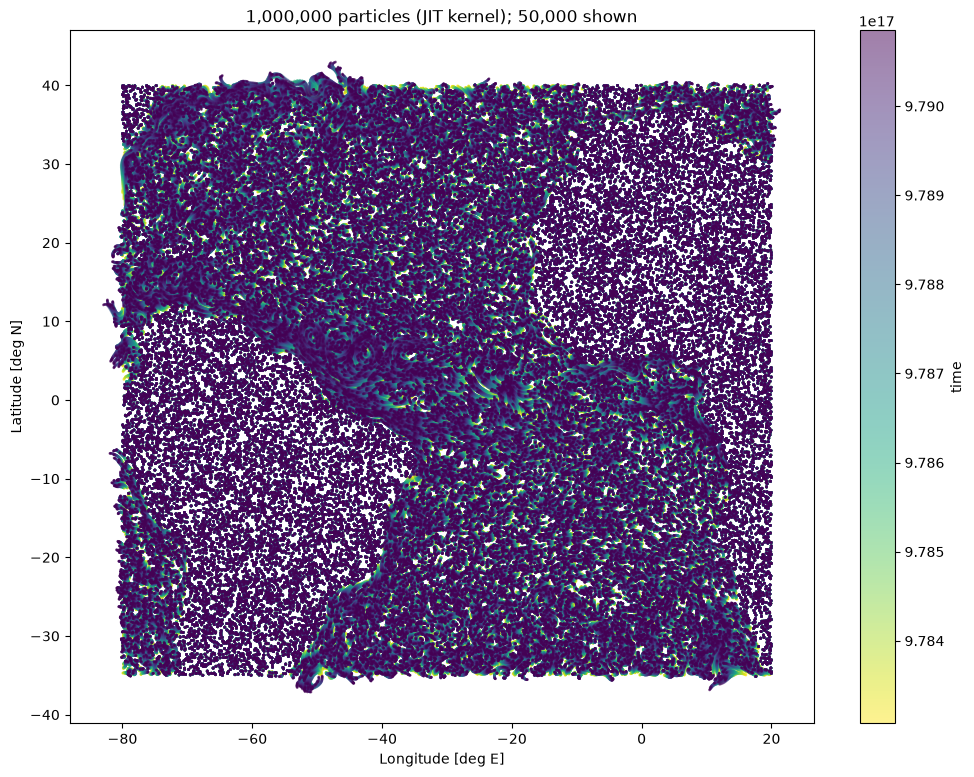

In [12]:
n_plot = min(50_000, n_particles)
plot_ids = rng.choice(n_particles, size=n_plot, replace=False)
mask = np.isin(df["particle_id"].to_numpy(), plot_ids)
_df = df[mask]

fig, ax = plt.subplots(figsize=(12, 9))
scatter = ax.scatter(
    _df["lon"], _df["lat"], c=_df["time"], s=1, alpha=0.5, cmap="viridis_r"
)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title(f"{n_particles:,} particles (JIT kernel); {n_plot:,} shown")
fig.colorbar(scatter, ax=ax, label="time")
plt.show()